# Setting things up
add a shortcut to this following folder into your own google drive, so you don't need your local harddrive stroage:

https://drive.google.com/drive/folders/16_5DuN6VQn3OvGvHYq9ky1vCeDx-HLAS?usp=sharing

The first few lines of this code will mount your drive and read the data via the shortcut. You may need to authorize Colab to read your Drive, just follow the code's output instructions.

# PAMAP2 Dataset structure

* 1 -> timestamp (s)
* 2 -> activityID (see II.2. for the mapping to the activities)
* 3 -> heart rate (bpm)
* 4 - 20 -> IMU hand
* 21 - 37 -> IMU chest
* 38 - 54 -> IMU ankle

## IMU Data structure
The IMU sensory data was recorded with a frequency of 100Hz and contains the following columns:
* 1 -> temperature (°C)
* 2 - 4 -> 3D-acceleration data (ms -2 ),  scale: ±16g, resolution: 13-bit
* 5 - 7 -> 3D-acceleration data (ms -2 ),  scale: ±6g, resolution: 13-bit *
* 8 - 10 -> 3D-gyroscope data (rad/s)
* 11 - 13 -> 3D-magnetometer data (μT)
* 14 - 17 -> orientation (invalid in this data collection)

## Activity definitions
The corresponding IDs for the activities are:
* 0 -> other (transient activities)
* 1 -> lying
* 2 -> sitting
* 3 -> standing
* 4 -> walking
* 5 -> running
* 6 -> cycling
* 7 -> Nordic walking
* 9 -> watching TV
* 10 -> computer work
* 11 -> car driving
* 12 -> ascending stairs
* 13 -> descending stairs
* 16 -> vacuum cleaning
* 17 -> ironing
* 18 -> folding laundry
* 19 -> house cleaning
* 20 -> playing soccer
* 24 -> rope jumping

The dataset is orignially published by a colleague from DFKI and is now listed here:
https://archive.ics.uci.edu/ml/datasets/PAMAP2+Physical+Activity+Monitoring
But you don't need to download it from the UCI link because the google drive folder linked at the beginning is the same.


Contacts:

Bo Zhou: bo.zhou@dfki.de



**Your task is simple, first run this code, the program will stop somewhere because we removed some key components. You need to fill these 'TODOs', there will be comments guiding you where you need to modify to continue the script as well as the expected output.**

# Program description
This program can be used to separate the data provided in the PAMAP2 dataset into different time windows.

The default value for Window size is 2 seconds with a step size of 0.5 seconds.

The default file for data extraction is Protocol/subject101.dat

In [1]:
import numpy as np
import pandas as pd
import glob
import os
import shutil

from sklearn.impute import SimpleImputer

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/arnavhoskote
/kaggle/input/datasets/arnavhoskote/ei-ex-1
/kaggle/input/datasets/arnavhoskote/ei-ex-1/PAMAP2_Dataset-20260611T114425Z-3-001
/kaggle/input/datasets/arnavhoskote/ei-ex-1/PAMAP2_Dataset-20260611T114425Z-3-001/PAMAP2_Dataset
/kaggle/input/datasets/arnavhoskote/ei-ex-1/PAMAP2_Dataset-20260611T114425Z-3-001/PAMAP2_Dataset/Protocol
/kaggle/input/datasets/arnavhoskote/ei-ex-1/PAMAP2_Dataset-20260611T114425Z-3-001/PAMAP2_Dataset/WindowSamples


In [3]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/arnavhoskote
/kaggle/input/datasets/arnavhoskote/ei-ex-1
/kaggle/input/datasets/arnavhoskote/ei-ex-1/PAMAP2_Dataset-20260611T114425Z-3-001
/kaggle/input/datasets/arnavhoskote/ei-ex-1/PAMAP2_Dataset-20260611T114425Z-3-001/PAMAP2_Dataset
/kaggle/input/datasets/arnavhoskote/ei-ex-1/PAMAP2_Dataset-20260611T114425Z-3-001/PAMAP2_Dataset/Protocol
/kaggle/input/datasets/arnavhoskote/ei-ex-1/PAMAP2_Dataset-20260611T114425Z-3-001/PAMAP2_Dataset/WindowSamples


In [4]:
DATASET_PATH = "/kaggle/input/datasets/arnavhoskote/dataset-ei-ex-1/PAMAP2_Dataset-20260611T114425Z-3-002/PAMAP2_Dataset/"
PROTOCOL_PATH = f"{DATASET_PATH}/Protocol"

In [5]:
import shutil
import os

DATASET_PATH = "/kaggle/input/datasets/arnavhoskote/ei-ex-1/PAMAP2_Dataset-20260611T114425Z-3-001/PAMAP2_Dataset"   # CHANGE THIS
PROTOCOL_PATH = f"{DATASET_PATH}/Protocol"

if not os.path.exists("Protocol"):
    shutil.copytree(PROTOCOL_PATH, "Protocol")

print("Protocol folder copied successfully.")

Protocol folder copied successfully.


In [6]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/arnavhoskote/ei-ex-1/PAMAP2_Dataset-20260611T114425Z-3-001/PAMAP2_Dataset/Protocol/subject101.dat",
    sep=' ',
    header=None
)

In [7]:
# These are the "Tableau 20" colors as RGB for plotting, don't mind these.
tableau20 = [(31, 119, 180), (174, 199, 232), (255, 127, 14), (255, 187, 120),
             (44, 160, 44), (152, 223, 138), (214, 39, 40), (255, 152, 150),
             (148, 103, 189), (197, 176, 213), (140, 86, 75), (196, 156, 148),
             (227, 119, 194), (247, 182, 210), (127, 127, 127), (199, 199, 199),
             (188, 189, 34), (219, 219, 141), (23, 190, 207), (158, 218, 229)]

# Scale the RGB values to the [0, 1] range, which is the format matplotlib accepts.
for i in range(len(tableau20)):
    r, g, b = tableau20[i]
    tableau20[i] = (r / 255., g / 255., b / 255.)

# Default file names, let's just look at subject101
fileName = "Protocol/subject101.dat"
outputFile = fileName.replace(".dat","")

# Default columns to extract from Dataset, the dataset contains more sensors, but we only consider these
cols = [0,4,5,6] # Timestamp + 3D Acceleration Hand

# Define default window size and time step in seconds
windowSize = 2    # (seconds)
windowStep = 0.5  # (seconds)

In [8]:
# function to replace Nan values in data
def replaceNan (data):
    # Use median as strategy to replace nan values
    imputer = SimpleImputer(missing_values=np.nan, strategy='median')
    # Fit data excluding the first column (timestamp)
    imputer.fit(data[:, 1:])
    data[:, 1:] = imputer.transform(data[:, 1:])

## Load and observe the data

Plot the data with the annotations overlapping

In [9]:
import numpy as np
# Import the dataset
dataset = pd.read_csv(fileName, header=None, sep=' ')

X = dataset.iloc[:, cols].values
y = dataset.iloc[:, 1].values # Activity labels

print("X shape: ",X.shape)
print("y shape: ",y.shape)

# Check if there are Nan values in the dataset
nanCount = np.isnan(X).sum()
print(nanCount," Nan values")

# Taking care of missing data (Nan)
print("Replacing Nan values ...")
replaceNan(X)

# Check again if there are Nan values in the dataset
nanCount = np.isnan(X).sum()
print(nanCount," Nan values")

X shape:  (376417, 4)
y shape:  (376417,)
4362  Nan values
Replacing Nan values ...
0  Nan values


In [10]:
def plot_fulldata(data, labels, regioncolors):
    # Define the upper limit, lower limit, interval of Y axis and colors
    y_LL = int( np.amin(data[:,1:])*1.1)
    y_UL = int( np.amax(data[:,1:])*1.1)
    y_interval = 10
    mycolors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange']


    fig, ax = plt.subplots(1,1,figsize=(20, 9), dpi= 200)
    columns = data.shape[1]-1

    # Draw Plot for each column in data
    for column in range(columns):
        plt.plot(data[:,0], data[:,column+1], lw=0.5, color=mycolors[column])


    # Draw Tick lines
    for ylin in range(y_LL, y_UL, y_interval):
        plt.hlines(ylin, xmin=0, xmax=data[-1,0], colors='white', alpha=1, linestyles="--", lw=0.5)

    # Decorations
    plt.tick_params(axis="both", which="both", bottom=False, top=False,
                    labelbottom=True, left=False, right=False, labelleft=True)

    # Lighten borders
    plt.gca().spines["top"].set_alpha(.3)
    plt.gca().spines["bottom"].set_alpha(.3)
    plt.gca().spines["right"].set_alpha(.3)
    plt.gca().spines["left"].set_alpha(.3)

    plt.title('Physical Activity Monitoring for %s'%(fileName.replace(".dat","").replace("Protocol/","")), fontsize=22)
    plt.yticks(range(y_LL, y_UL, y_interval), [str(y) for y in range(y_LL, y_UL, y_interval)], fontsize=12)
    plt.xlabel('Time (s)')
    plt.ylabel('3D-acceleration data($ms^{-2}$)')
    plt.ylim(y_LL, y_UL)
    plt.xlim(0, data[-1,0])

    # Detect a change of activities
    label_ch = np.where(np.diff(labels) != 0)[0]
    # Add extreme values (0 and data size)
    label_ch = np.insert(label_ch,0,0)
    label_ch = np.append(label_ch,data[:,0].shape[0]-1)

    # New list to store plotted labels
    ex_label = []

    #Color the regions according to the activity
    for reg in range (len(label_ch)-1):
        # Find the corresponding color to the activity
        colour = regioncolors[labels[label_ch[reg+1]]]
        # Detect if the label is repeated
        activity_id = labels[label_ch[reg+1]]
        if activity_id in ex_label:
            lab = "_"
        else:
            ex_label.append(activity_id)
            lab = activity_id
        # Fill the corresponding region with color
        ax.axvspan(data[label_ch[reg],0], data[label_ch[reg+1],0], alpha=0.5, color=colour,label=lab)

    # Get the labels and handles to sort them according to the activity ID
    xhandles, xlabels = ax.get_legend_handles_labels()
    # sort both labels and handles by labels
    xlabels, xhandles = zip(*sorted(zip(xlabels, xhandles), key=lambda x: int(''.join(filter(str.isdigit, x[0])))))
    ax.legend(xhandles, xlabels,title="Activity IDs", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

    plt.show()

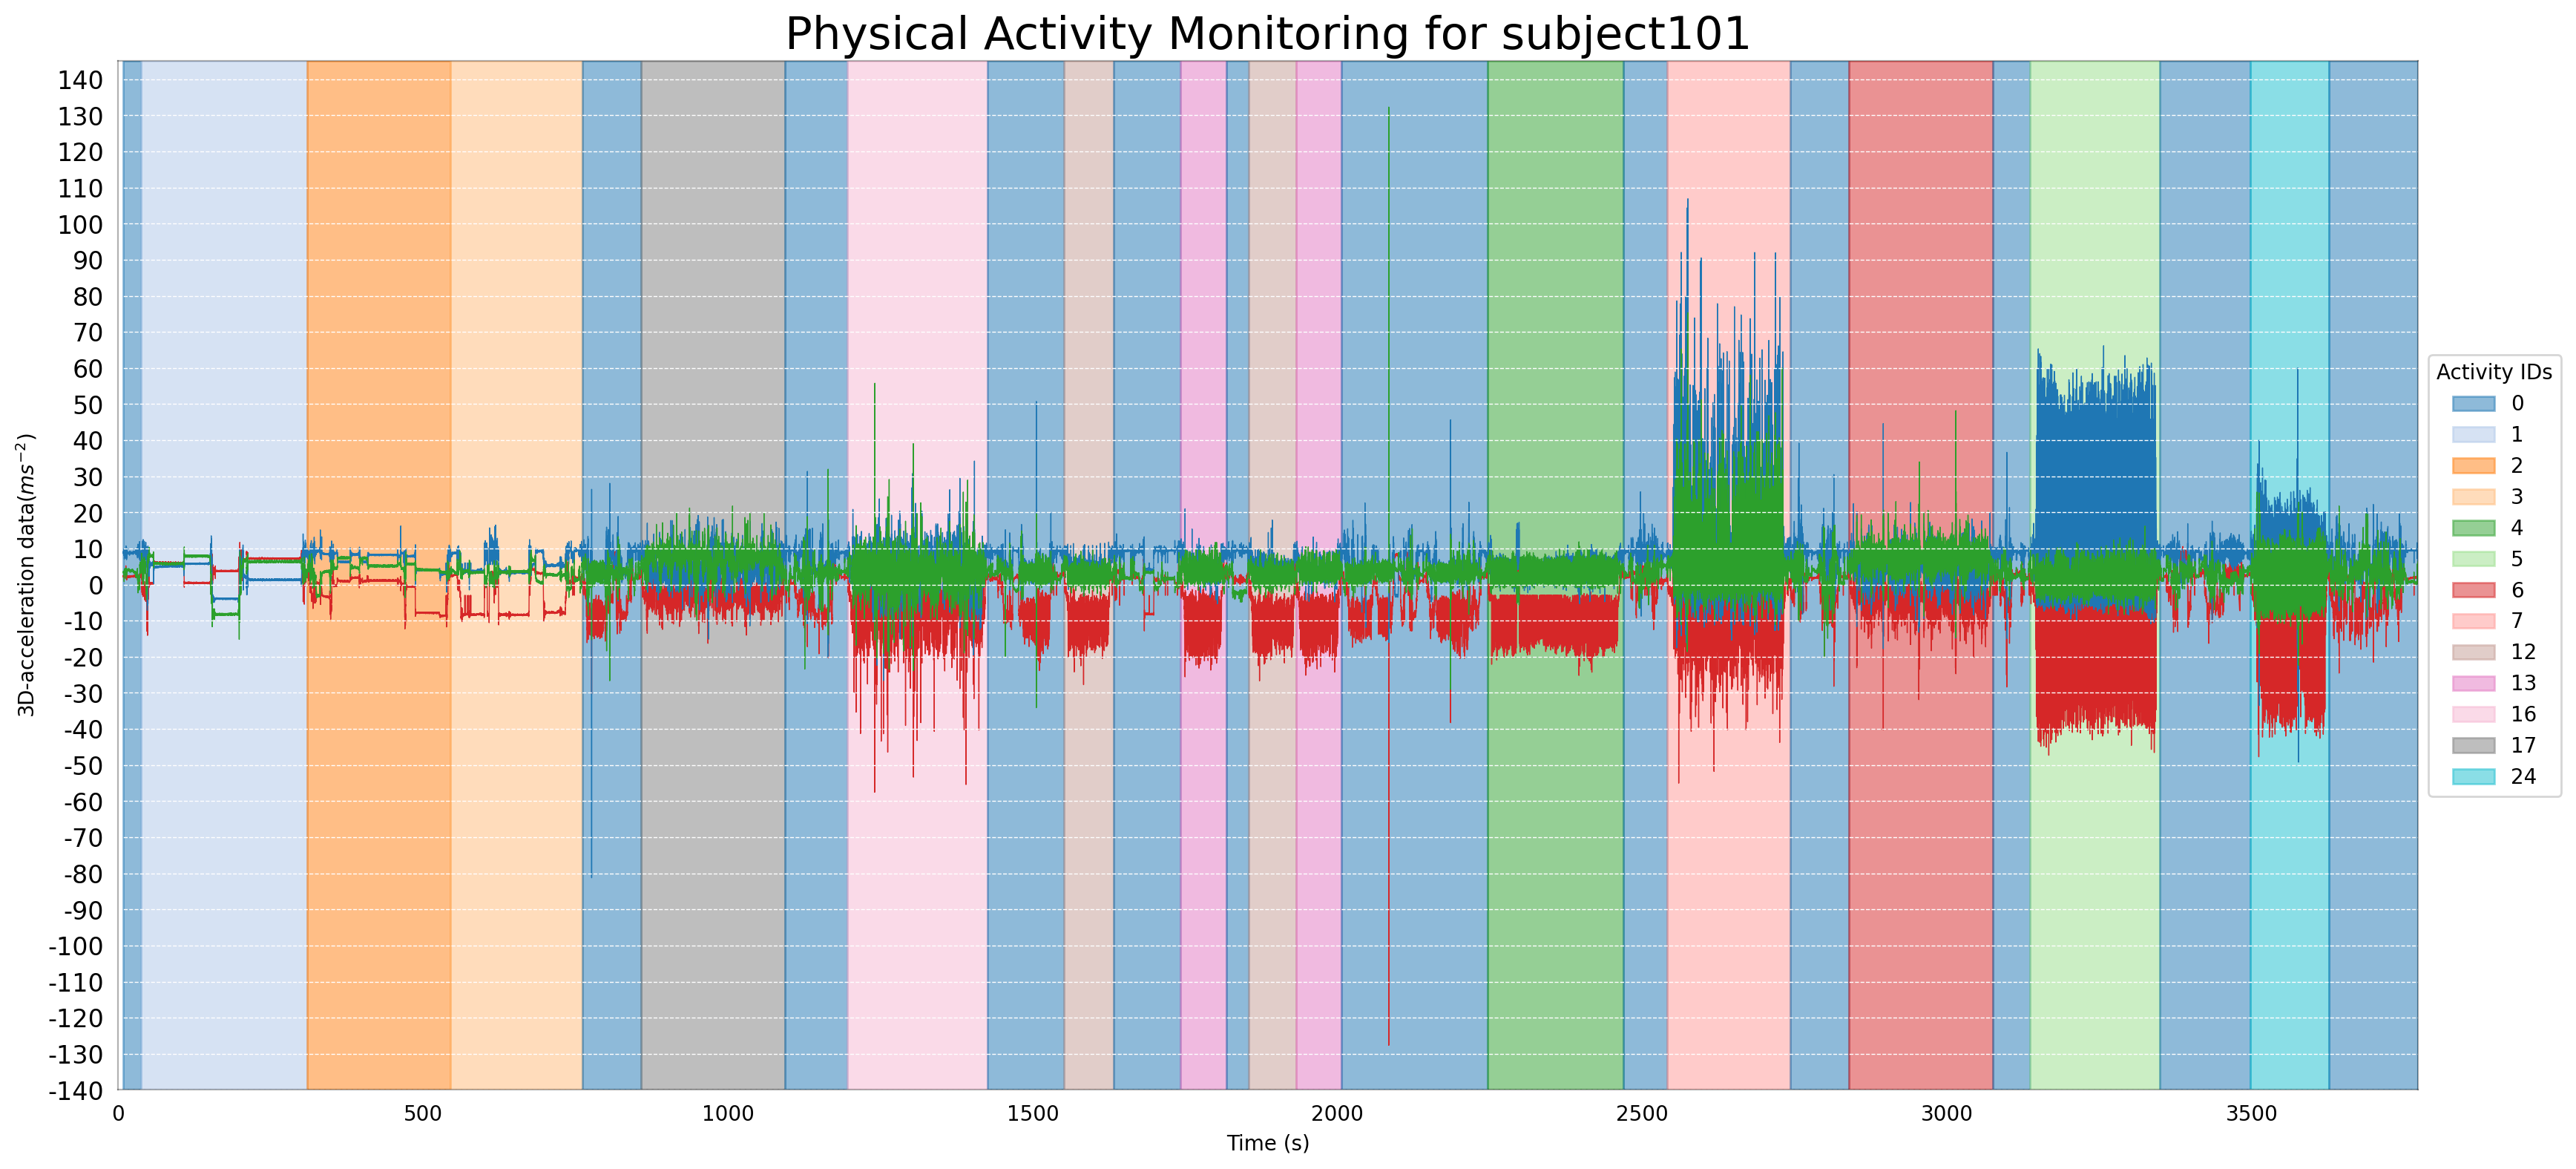

In [11]:
# Create list with the activity IDs of dataset
activities = [0,1,2,3,4,5,6,7,9,10,11,12,13,16,17,18,19,20,24]

# Assign one color to each activity
regioncolors = {activities[i]: tableau20[i] for i in range(len(activities))}

plot_fulldata(X,y,regioncolors)


# Split the data
If you haven't noticed after trying to run the entire code, there are missing segments in the splitInWindows() function.

In [12]:
# Split data into windows
def splitInWindows (data,labels, wSize, wStep):
    # Divide data according to the different activities
    change_indices = np.where(np.diff(labels) != 0)[0] + 1
    X_activities = np.split(data, change_indices)
    y_activities = labels[np.insert(change_indices, 0, 0)]

    print("X list shape ", len(X_activities))
    print("y list shape ", len(y_activities))

    # how fast is the sample rate?
    m_samplerate = np.round(1/np.diff(data[:,0]).mean())
    print("sampling rate", m_samplerate)

    # Convert size of window and time step into data points
    m_windowsize = int(m_samplerate * wSize)
    m_windowstep = int(m_samplerate * wStep)

    # destination to store the windows
    X_window = []
    y_window = []

    # Divide data in windows
    for i in range(len(X_activities)):
        activity_data = X_activities[i]
        activity_label = y_activities[i]
        
        # Calculate sliding windows within this activity block
        for start_pos in range(0, len(activity_data) - m_windowsize + 1, m_windowstep):
            end_pos = start_pos + m_windowsize
            m_window_data = activity_data[start_pos:end_pos]
            
            X_window.append(m_window_data)
            y_window.append(activity_label)
            
    X_window = np.stack(X_window)
    y_window = np.stack(y_window)

    return X_window, y_window, m_samplerate

In [13]:
# Split Data into sliding windows with the above function
X_w, Y_w, srate = splitInWindows(X,y,windowSize,windowStep)

# Visualize data shape (windows, samples, channels)
print("Data shape ", X_w.shape)   # expected (7413, 200, 4) with default parameters
print("Labels shape ", Y_w.shape) # expected (7413,) with default parameters


X list shape  26
y list shape  26
sampling rate 100.0
Data shape  (7439, 200, 4)
Labels shape  (7439,)


expected output:
```
X shape  26
y shape  25
X shape in activity  0 (2928, 4)
X shape in activity  1 (27187, 4)
X shape in activity  2 (23480, 4)
X shape in activity  3 (21717, 4)
X shape in activity  4 (9655, 4)
X shape in activity  5 (23573, 4)
X shape in activity  6 (10220, 4)
X shape in activity  7 (22941, 4)
X shape in activity  8 (12580, 4)
X shape in activity  9 (8120, 4)
X shape in activity  10 (10995, 4)
X shape in activity  11 (7480, 4)
X shape in activity  12 (3686, 4)
X shape in activity  13 (7770, 4)
X shape in activity  14 (7419, 4)
X shape in activity  15 (24008, 4)
X shape in activity  16 (22253, 4)
X shape in activity  17 (7163, 4)
X shape in activity  18 (20265, 4)
X shape in activity  19 (9656, 4)
X shape in activity  20 (23575, 4)
X shape in activity  21 (6071, 4)
X shape in activity  22 (21265, 4)
X shape in activity  23 (14881, 4)
X shape in activity  24 (12912, 4)
X shape in activity  25 (14617, 4)
sampling rate 100.0
Data shape  (7413, 200, 4)
Labels shape  (7413,)
```



**Let's see the seperated windows from different classes**

In [14]:
def plot_windows(data,labels,srate,numcolumns,window):
    # Identify indices when there is a change of activities
    label_ch = np.where(np.diff(labels) != 0)[0]
    # Add corresponding activity label to the index
    label_ch = np.column_stack((label_ch,labels[np.where(np.diff(labels) != 0)[0]]))
    # Find the different types of activities performed by the person
    activityLabels = np.unique(labels)
    # Remove Activity 0 (transient activities)
    activityLabels = np.delete(activityLabels,np.where(activityLabels == 0))

    # Define the number of columns and rows to visualize data
    row = int(np.ceil(len(activityLabels)/numcolumns))

    # Set the time axis
    time = np.linspace(0,data.shape[1]/srate,data.shape[1],endpoint=False)

    # Plot windows for each activity
    fig, axs = plt.subplots(row,numcolumns,figsize=(15,10),sharex=True)

    for act in range(len(activityLabels)):
        indx = int(act / numcolumns)
        indy = act % numcolumns
        index_act = label_ch[np.argwhere(label_ch == activityLabels[act])[0][0]][0]
        axs[indx,indy].plot(time,data[index_act+window,:,1:])
        axs[indx,indy].set_title('Activity ID - %d'%(activityLabels[act]), fontsize=12)
    fig.suptitle('Window %d for different activities of %s'%(window,fileName.replace(".dat","").replace("Protocol/","")),fontsize=22)
    fig.text(0.5, 0.08, 'Time (s)', ha='center')
    fig.text(0.08, 0.5, '3D-acceleration data($ms^{-2}$)', va='center', rotation='vertical')
    plt.show()




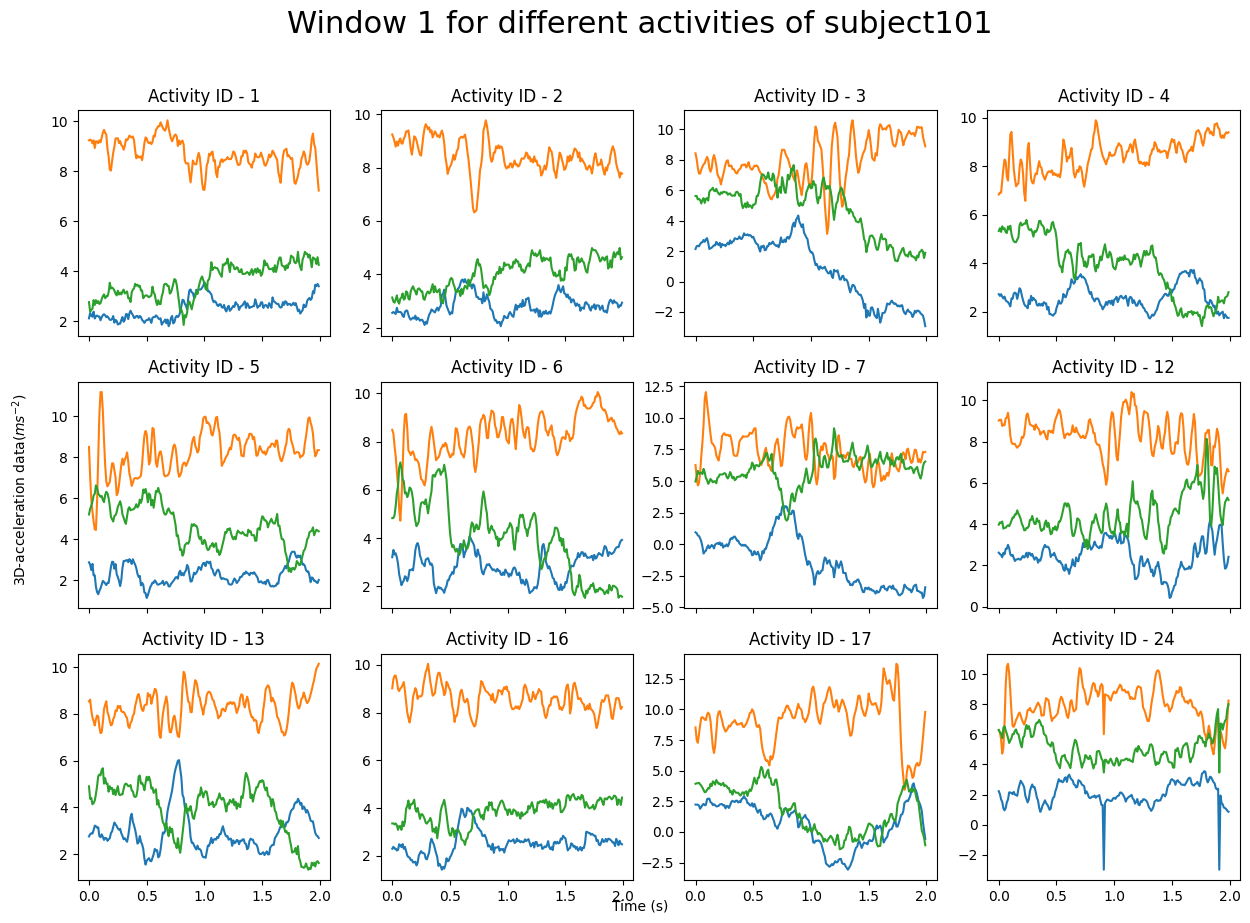

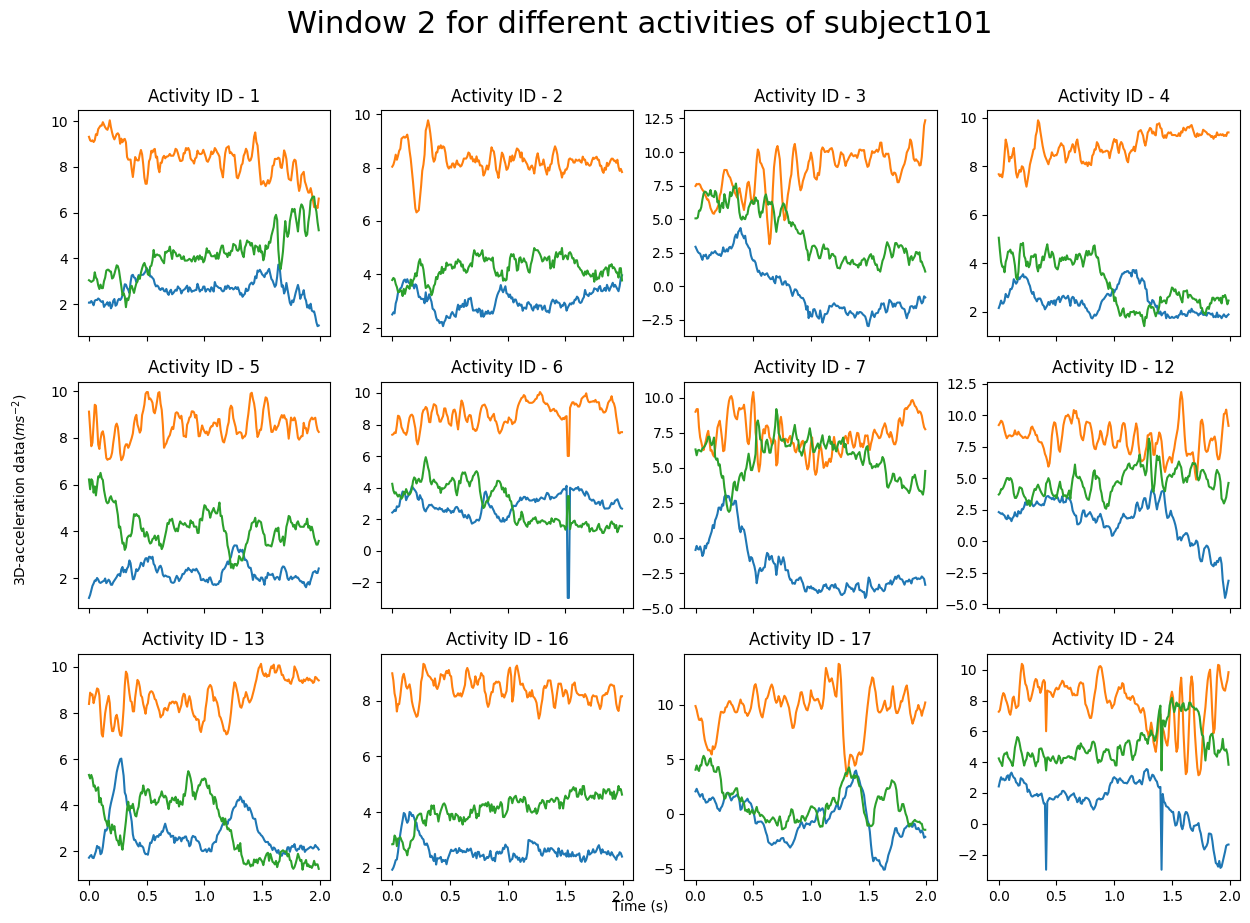

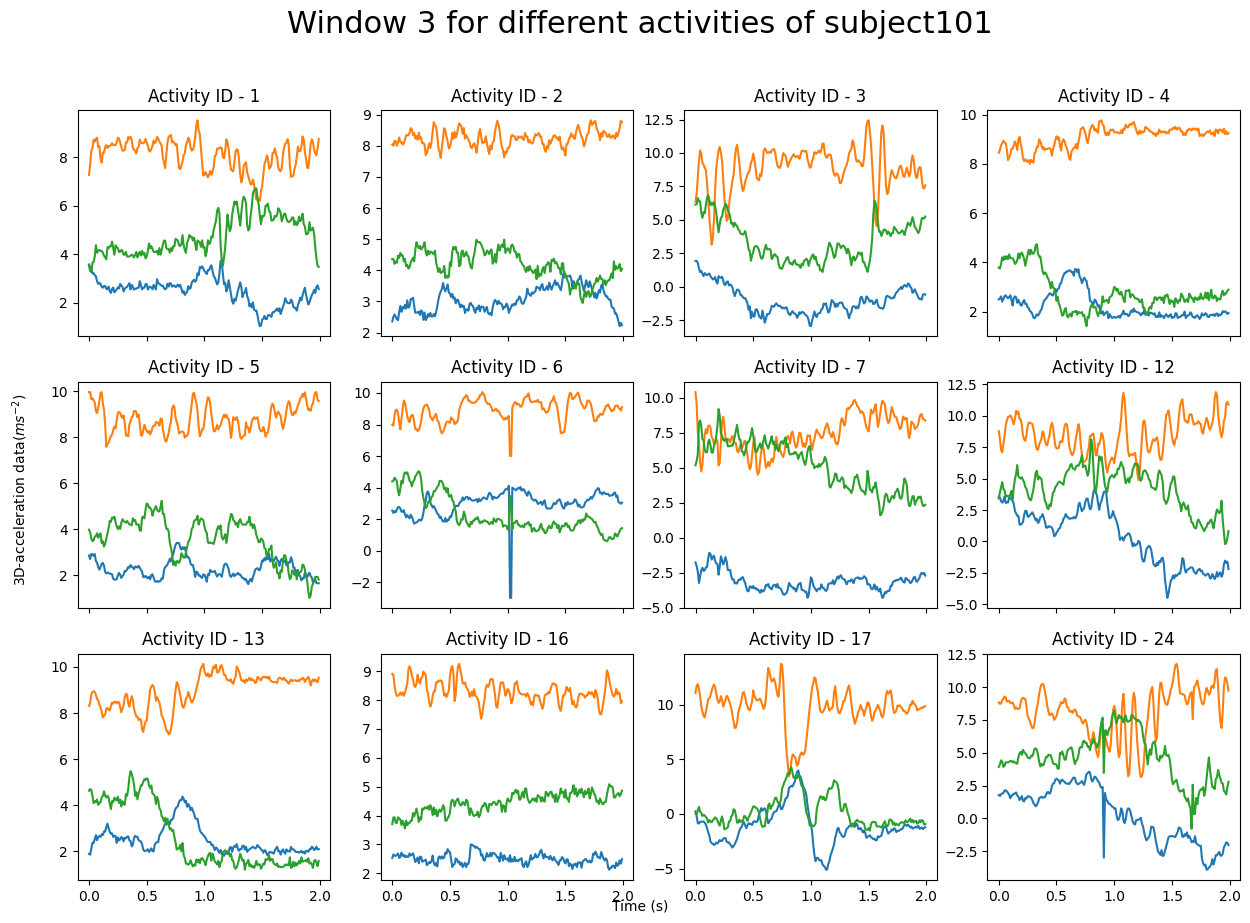

In [15]:
# Define the number of columns to plot data
col = 4
# Which window you want to visualize
window = 1

# Plot some windows
plot_windows(X_w, Y_w, srate,col,window)
plot_windows(X_w, Y_w, srate,col,2)
plot_windows(X_w, Y_w, srate,col,3)

With our default settings, the plot should look like the following:

In [16]:
# Save data
np.savez(outputFile,X_w,Y_w)
print("File saved to", outputFile)

File saved to Protocol/subject101


In [17]:
# Load data
data = np.load("Protocol/subject101.npz")
X = data['arr_0']
y = data['arr_1']

print("Data shape ", X.shape)
print("Labels shape ", y.shape)

Data shape  (7439, 200, 4)
Labels shape  (7439,)


In [18]:
# Split data for all the .dat files in a folder
def splitFolderData(Folder):
    search = Folder + "/" + "*.dat"
    for file in glob.glob(search):
        print("Opening file: ", file)
        outputFile = file.replace(".dat","")
        dataset = pd.read_csv(file, header=None, sep=' ')

        X = dataset.iloc[:, cols].values
        y = dataset.iloc[:, 1].values # Activity labels

        print("\nX shape: ",X.shape)
        print("y shape: ",y.shape)

        print("\nDealing with Nan Values ...\n")
        # Check if there are Nan values in the dataset
        nanCount = np.isnan(X).sum()
        print("Found ", nanCount," Nan values")

        # Taking care of missing data (Nan)
        print("Replacing Nan values ...")
        replaceNan(X)

        # Check again if there are Nan values in the dataset
        nanCount = np.isnan(X).sum()
        print("Found ", nanCount," Nan values after preprocessing.\n")

        # Split Data into sliding windows
        print("Splitting data into windows of %5.2f seconds with an overlap of %5.2f seconds"%(windowSize,windowStep))
        X_w, Y_w,_ = splitInWindows(X,y,windowSize,windowStep)

        # Visualize data shape (windows, samples, channels)
        print("Data shape ", X_w.shape)
        print("Labels shape ", Y_w.shape)

        # Save data
        np.savez(outputFile,X_w,Y_w)
        print("\nFile saved to", outputFile,"\n")

In [19]:
# Test with all the folders, this will process all the subjects' files in the dataset.
splitFolderData("Protocol")

Opening file:  Protocol/subject107.dat

X shape:  (313599, 4)
y shape:  (313599,)

Dealing with Nan Values ...

Found  4518  Nan values
Replacing Nan values ...
Found  0  Nan values after preprocessing.

Splitting data into windows of  2.00 seconds with an overlap of  0.50 seconds
X list shape  24
y list shape  24
sampling rate 100.0
Data shape  (6191, 200, 4)
Labels shape  (6191,)

File saved to Protocol/subject107 

Opening file:  Protocol/subject108.dat

X shape:  (408031, 4)
y shape:  (408031,)

Dealing with Nan Values ...

Found  6453  Nan values
Replacing Nan values ...
Found  0  Nan values after preprocessing.

Splitting data into windows of  2.00 seconds with an overlap of  0.50 seconds
X list shape  26
y list shape  26
sampling rate 100.0
Data shape  (8067, 200, 4)
Labels shape  (8067,)

File saved to Protocol/subject108 

Opening file:  Protocol/subject103.dat

X shape:  (252833, 4)
y shape:  (252833,)

Dealing with Nan Values ...

Found  1566  Nan values
Replacing Nan values

In [20]:
##############################################################
# EXERCISE 2 STARTS HERE
# Uses output from Exercise 1 directly
##############################################################

print("Windowed Data Shape:", X_w.shape)
print("Windowed Labels Shape:", Y_w.shape)

# Keep only accelerometer x,y,z channels
# Column 0 = timestamp
# Columns 1,2,3 = accelerometer axes

X = X_w[:, :, 1:4]
y = Y_w

print("\nAccelerometer data shape:", X.shape)
print("Labels shape:", y.shape)

print("\nActivity IDs present:")
print(np.unique(y))

numClass = len(np.unique(y))

Windowed Data Shape: (7439, 200, 4)
Windowed Labels Shape: (7439,)

Accelerometer data shape: (7439, 200, 3)
Labels shape: (7439,)

Activity IDs present:
[ 0  1  2  3  4  5  6  7 12 13 16 17 24]


In [21]:
##############################################################
# Feature Extraction Functions
##############################################################

def f_normalize(m_input):
    m_mu = m_input.mean()
    m_delta = m_input.std()

    return (m_input - m_mu) / (m_delta + 1e-8)


def f_calvector(m_input):
    return np.sqrt(np.sum(np.square(m_input), axis=1))


def f_features(m_input, numFeatures):

    m_norm = f_normalize(m_input)

    m_features = np.zeros((1, numFeatures))

    # Mean
    m_features[0,0] = m_input.mean()

    # Standard deviation
    m_features[0,1] = m_input.std()

    # Range
    m_features[0,2] = m_input.max() - m_input.min()

    # Interquartile Range
    m_features[0,3] = (
        np.percentile(m_input,75)
        - np.percentile(m_input,25)
    )

    # Maximum FFT component
    m_features[0,4] = np.fft.fft(m_norm).real.max()

    # Mean FFT magnitude
    m_features[0,5] = np.abs(np.fft.fft(m_norm)).mean()

    return m_features


In [22]:
##############################################################
# Calculate Features
##############################################################

numFeatures = 6

X_features = np.zeros((len(X), numFeatures))

print("\nExtracting Features...")

for i in range(len(X)):
    X_features[i,:] = f_features(
        f_calvector(X[i,:,:]),
        numFeatures
    )

print("Feature matrix shape:", X_features.shape)


Extracting Features...
Feature matrix shape: (7439, 6)


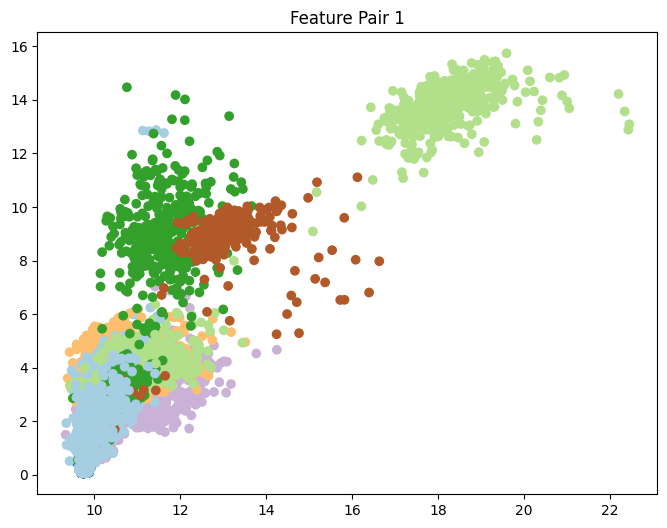

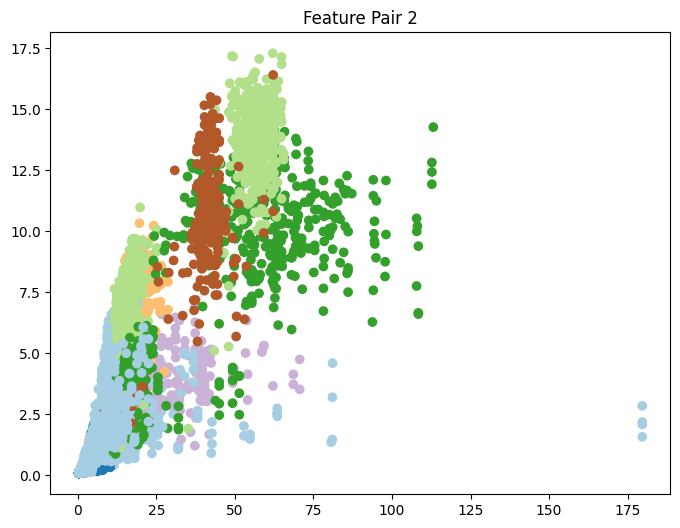

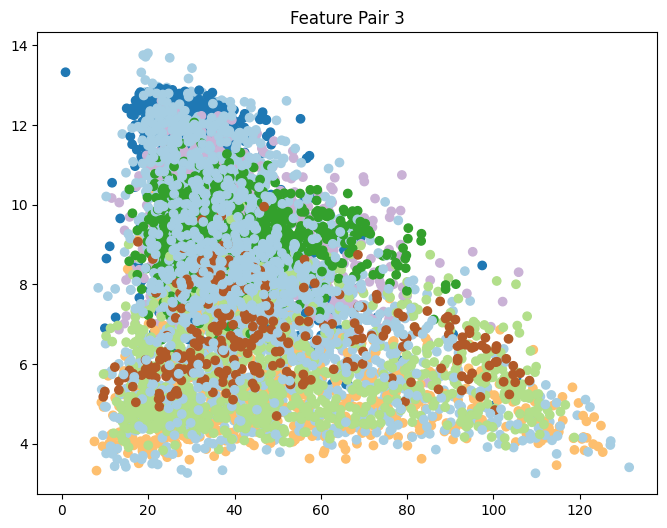

In [23]:
##############################################################
# Visualize Features
##############################################################

plt.figure(figsize=(8,6))
plt.scatter(
    X_features[:,0],
    X_features[:,1],
    c=y,
    cmap=plt.cm.Paired
)
plt.title("Feature Pair 1")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(
    X_features[:,2],
    X_features[:,3],
    c=y,
    cmap=plt.cm.Paired
)
plt.title("Feature Pair 2")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(
    X_features[:,4],
    X_features[:,5],
    c=y,
    cmap=plt.cm.Paired
)
plt.title("Feature Pair 3")
plt.show()


Running KNN on original dataset...



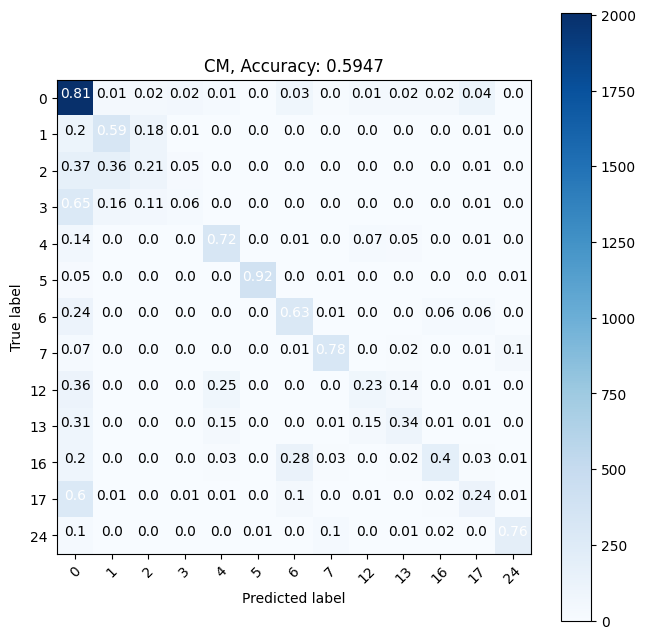


Confusion Matrix

[[2007   33   47   53   27    0   75   11   37   42   47  107    2]
 [ 108  318   97    7    0    0    2    2    0    0    1    5    0]
 [ 172  170   97   22    0    0    2    0    0    0    0    3    0]
 [ 282   68   49   28    0    0    0    0    0    0    0    4    0]
 [  61    0    0    0  318    0    3    0   31   21    2    6    0]
 [  22    0    0    0    0  390    1    3    0    0    1    2    3]
 [ 111    1    0    0    1    0  295    4    0    0   30   26    0]
 [  27    1    0    0    0    0    4  313    1    9    1    5   41]
 [ 112    0    0    1   77    0    1    0   71   43    1    4    1]
 [  90    0    1    1   45    0    1    2   45  100    2    4    0]
 [  92    1    0    0   12    0  129   13    0    8  183   13    4]
 [ 280    3    0    5    3    0   47    2    4    1   10  110    3]
 [  25    0    0    0    1    2    1   25    0    2    5    0  194]]

Column sums:
[3389.  595.  291.  117.  484.  392.  561.  375.  189.  226.  283.  289.
  248.]



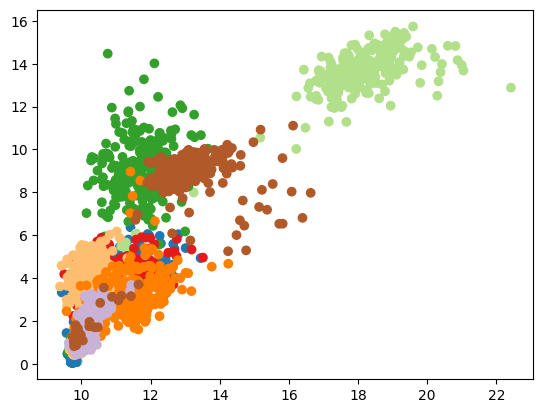

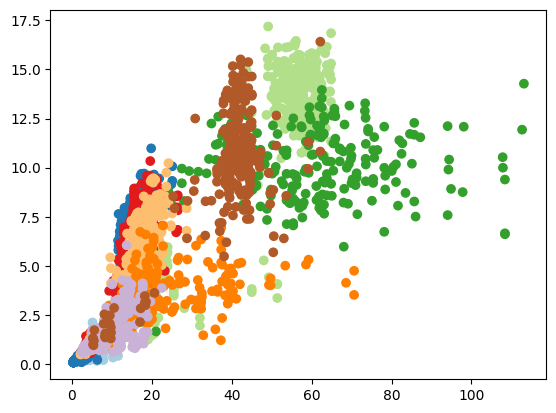

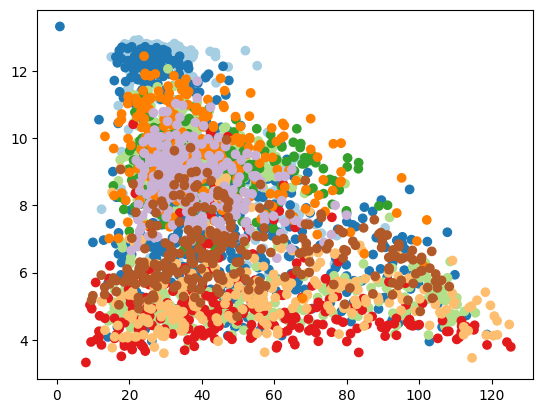


Running KNN on balanced dataset...



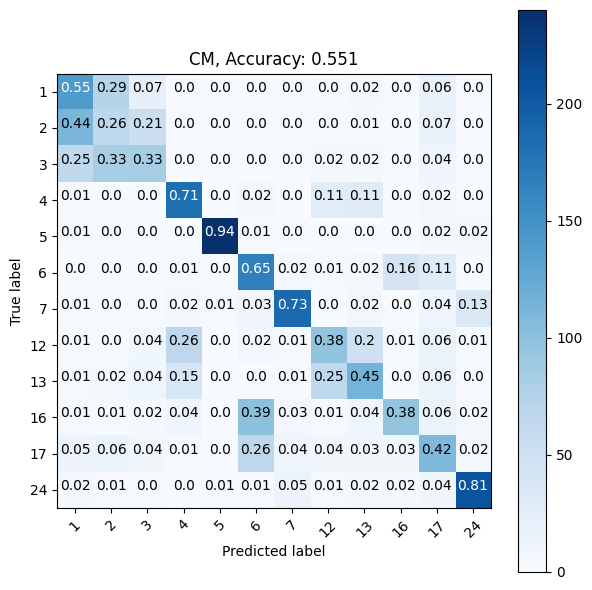


Balanced Confusion Matrix

[[140  73  19   1   0   0   0   1   4   0  16   1]
 [111  66  54   1   0   1   1   1   2   0  18   0]
 [ 65  83  85   1   0   0   1   4   4   0  11   1]
 [  2   1   1 182   0   4   0  28  29   1   6   1]
 [  2   1   0   0 240   2   0   0   0   0   5   5]
 [  1   1   0   2   1 165   6   2   5  42  29   1]
 [  3   1   0   4   2   8 186   0   6   0  11  34]
 [  3   1   9  66   0   6   2  97  50   3  15   3]
 [  3   5  10  39   0   1   2  65 114   1  15   0]
 [  3   2   4  11   0 100   7   3  10  96  15   4]
 [ 14  15   9   3   0  66  10   9   8   8 108   5]
 [  5   2   1   0   3   3  14   3   4   4   9 207]]

Column sums:
[352. 251. 192. 310. 246. 356. 229. 213. 236. 155. 258. 262.]

Row sums:
[255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255.]


In [24]:
##############################################################
# K-FOLD VALIDATION
##############################################################
import sklearn as skl
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
import itertools

import sklearn as skl

from sklearn import neighbors
from sklearn import metrics

from sklearn.model_selection import (
    StratifiedKFold,
    KFold,
    cross_validate
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
def k_fold_validation(X, y, model_type='knn', folds=5):

    numClass = len(np.unique(y))

    kf = skl.model_selection.StratifiedKFold(
        n_splits=folds,
        shuffle=True,
        random_state=42
    )

    m_cm_All = np.zeros((numClass, numClass))

    class_labels = np.unique(y)

    for train_index, test_index in kf.split(X, y):

        X_train = X[train_index, :]
        X_test  = X[test_index, :]

        y_train = y[train_index]
        y_test  = y[test_index]

        ##################################################
        # MODEL
        ##################################################

        if model_type == 'knn':
            m_model = neighbors.KNeighborsClassifier(
                n_neighbors=5
            )

        elif model_type == 'svm':
            m_model = skl.svm.SVC(kernel='rbf')

        ##################################################
        # TRAIN
        ##################################################

        m_model.fit(X_train, y_train)

        ##################################################
        # PREDICT
        ##################################################

        y_predict = m_model.predict(X_test)

        ##################################################
        # CONFUSION MATRIX
        ##################################################

        m_cm = skl.metrics.confusion_matrix(
            y_test,
            y_predict,
            labels=class_labels
        )

        m_cm_All += m_cm

    return m_cm_All


##############################################################
# CONFUSION MATRIX PLOT
##############################################################

def plot_confusion_matrix(cm, class_names):

    figure = plt.figure(
        figsize=(len(class_names)/2, len(class_names)/2)
    )

    plt.imshow(
        cm,
        interpolation='nearest',
        cmap=plt.cm.Blues
    )

    acc = np.sum(
        cm * np.eye(len(class_names))
    ) / np.sum(cm)

    plt.title(
        "CM, Accuracy: " + str(round(acc, 4))
    )

    plt.colorbar()

    tick_marks = np.arange(len(class_names))

    plt.xticks(
        tick_marks,
        class_names,
        rotation=45
    )

    plt.yticks(
        tick_marks,
        class_names
    )

    cm_norm = np.around(
        cm.astype('float')
        / cm.sum(axis=1)[:, np.newaxis],
        decimals=2
    )

    threshold = cm_norm.max() / 2.

    for i, j in itertools.product(
        range(cm_norm.shape[0]),
        range(cm_norm.shape[1])
    ):

        color = (
            "white"
            if cm_norm[i, j] > threshold
            else "black"
        )

        plt.text(
            j,
            i,
            cm_norm[i, j],
            horizontalalignment="center",
            color=color
        )

    plt.tight_layout()

    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    plt.show()

    return figure


##############################################################
# ORIGINAL DATASET EVALUATION
##############################################################

print("\nRunning KNN on original dataset...\n")

m_cm_All = k_fold_validation(
    X_features,
    y,
    model_type='knn',
    folds=5
)

plot_confusion_matrix(
    m_cm_All,
    np.unique(y).astype(int)
)

print("\nConfusion Matrix\n")
print(m_cm_All.astype(int))

print("\nColumn sums:")
print(np.sum(m_cm_All, axis=0))

print("\nRow sums:")
print(np.sum(m_cm_All, axis=1))


##############################################################
# CLASS DISTRIBUTION
##############################################################

m_labels = np.unique(y)

m_counts = np.zeros(numClass)

for i in range(numClass):
    m_counts[i] = np.sum(y == m_labels[i])

print("\nClass Counts")
print(m_counts)

m_least = int(m_counts.min())

print("\nSmallest Class Size")
print(m_least)


##############################################################
# BALANCE DATASET
##############################################################

X_balanced = np.zeros((0, numFeatures))
y_balanced = np.zeros((0))

for i in range(1, numClass):

    rand_ind = np.random.permutation(
        int(m_counts[i])
    )

    m_subind = np.where(y == m_labels[i])

    m_subind_balanced = (
        m_subind[0][rand_ind[:m_least]]
    )

    X_balanced = np.concatenate(
        (
            X_balanced,
            X_features[m_subind_balanced, :]
        )
    )

    y_balanced = np.concatenate(
        (
            y_balanced,
            y[m_subind_balanced]
        )
    )

y_balanced = y_balanced.astype(int)

##############################################################
# CHECK BALANCED DISTRIBUTION
##############################################################

m_counts_balanced = np.zeros(numClass)

for i in range(1, numClass):

    m_counts_balanced[i] = np.sum(
        y_balanced == m_labels[i]
    )

print("\nBalanced Counts")
print(m_counts_balanced)


##############################################################
# VISUALIZE BALANCED DATA
##############################################################

plt.figure()
plt.scatter(
    X_balanced[:,0],
    X_balanced[:,1],
    c=y_balanced,
    cmap=plt.cm.Paired
)

plt.figure()
plt.scatter(
    X_balanced[:,2],
    X_balanced[:,3],
    c=y_balanced,
    cmap=plt.cm.Paired
)

plt.figure()
plt.scatter(
    X_balanced[:,4],
    X_balanced[:,5],
    c=y_balanced,
    cmap=plt.cm.Paired
)

plt.show()


##############################################################
# BALANCED DATASET EVALUATION
##############################################################

print("\nRunning KNN on balanced dataset...\n")

m_cm_All = k_fold_validation(
    X_balanced,
    y_balanced,
    model_type='knn',
    folds=5
)

plot_confusion_matrix(
    m_cm_All,
    np.unique(y_balanced).astype(int)
)

print("\nBalanced Confusion Matrix\n")
print(m_cm_All.astype(int))

print("\nColumn sums:")
print(np.sum(m_cm_All, axis=0))

print("\nRow sums:")
print(np.sum(m_cm_All, axis=1))